In [32]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots


plt.style.use(
    [
        "science",
        "no-latex",
    ]
)

PROJECT_ROOT = Path.cwd().parents[2]

print("Project root:", PROJECT_ROOT)

Project root: c:\Users\abd93000\PycharmProjects\cnt_project_v2


In [33]:
GT_FEATURE_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "gt_feature_extraction_rle"
    / "eval"
    / "features"
    / "gt_cnt_features_rle"
)

NANOVISION_FEATURE_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / (
        "fluo_edt_edt_score_symmetry_score_"
        "without_smoothing_20260610_1004 - Copy"
    )
    / "eval"
    / "features"
    / "pred_cnt_features_rle"
)

CPSAM_FEATURE_DIR = (
    PROJECT_ROOT
    / "global_outputs"
    / "runs"
    / "cpsam_v2_legacy_seed42_best_validation_optimized"
    / "eval"
    / "features"
    / "pred_cnt_features_rle"
)

for name, path in {
    "Ground truth": GT_FEATURE_DIR,
    "NanoVision": NANOVISION_FEATURE_DIR,
    "CPSAM v2": CPSAM_FEATURE_DIR,
}.items():
    print(name, path.is_dir())

Ground truth True
NanoVision True
CPSAM v2 True


In [34]:
gt_objects = pd.read_csv(
    GT_FEATURE_DIR
    / "object_level_features.csv"
)

nanovision_objects = pd.read_csv(
    NANOVISION_FEATURE_DIR
    / "object_level_features.csv"
)

cpsam_objects = pd.read_csv(
    CPSAM_FEATURE_DIR
    / "object_level_features.csv"
)

gt_objects["model"] = "Ground truth"
nanovision_objects["model"] = "NanoVision"
cpsam_objects["model"] = "CPSAM v2"

In [35]:
gt_images = pd.read_csv(
    GT_FEATURE_DIR
    / "image_level_features.csv"
)

nanovision_images = pd.read_csv(
    NANOVISION_FEATURE_DIR
    / "image_level_features.csv"
)

cpsam_images = pd.read_csv(
    CPSAM_FEATURE_DIR
    / "image_level_features.csv"
)

gt_images["model"] = "Ground truth"
nanovision_images["model"] = "NanoVision"
cpsam_images["model"] = "CPSAM v2"

image_features = pd.concat(
    [
        gt_images,
        nanovision_images,
        cpsam_images,
    ],
    ignore_index=True,
)

print(
    image_features.groupby("model").size()
)

display(
    image_features[
        [
            "image_id",
            "model",
            "line_density_mean",
            "line_density_std",
            "line_density_max",
        ]
    ].head()
)

model
CPSAM v2        30
Ground truth    30
NanoVision      30
dtype: int64


,image_id,model,line_density_mean,line_density_std,line_density_max
0,1293-22_3_2_20230306222551,Ground truth,5.949219,1.518557,10.0
1,400-1093-w11-c1p1-befo3-10sp-15flow_left,Ground truth,7.621094,2.316927,13.0
2,400-1093-w11-c1p2-befo3-20sp-15flow_left,Ground truth,10.703125,2.674706,17.0
3,400-1093-w13-c1-p1-10sp-15flow_left,Ground truth,7.984375,2.084108,14.0
4,400-1093-w16-c-1-p1-10sp-15flow_left,Ground truth,15.148438,2.262430,21.0


In [36]:
object_features = pd.concat(
    [
        gt_objects,
        nanovision_objects,
        cpsam_objects,
    ],
    ignore_index=True,
)

print(
    object_features.groupby("model").size()
)

display(object_features.head())

model
CPSAM v2        2853
Ground truth    2912
NanoVision      3849
dtype: int64


,image_id,image_file,annotation_id,object_index,area_pixels2,area_um2,perimeter,perimeter_um,length,length_um,width,width_um,aspect_ratio,orientation_angle,n_connected_components,model
0,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.tif,1,0,57.0,0.021744,55.122201,1.076605,27.071068,0.528732,2.159313,0.042174,12.536890,-10.055091,1.0,Ground truth
1,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.tif,2,1,88.0,0.033569,82.818055,1.617540,41.556349,0.811647,2.283409,0.044598,18.199256,-74.379494,1.0,Ground truth
2,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.tif,3,2,80.0,0.030518,64.316941,1.256190,31.798990,0.621074,2.805189,0.054789,11.335773,-59.429681,1.0,Ground truth
3,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.tif,4,3,78.0,0.029755,69.870545,1.364659,34.142136,0.666839,2.400852,0.046892,14.220842,71.945719,1.0,Ground truth
4,1293-22_3_2_20230306222551,1293-22_3_2_20230306222551.tif,5,4,77.0,0.029373,63.991619,1.249836,31.041631,0.606282,2.695879,0.052654,11.514476,-37.134166,1.0,Ground truth


In [37]:
print(
    object_features.columns.tolist()
)

['image_id', 'image_file', 'annotation_id', 'object_index', 'area_pixels2', 'area_um2', 'perimeter', 'perimeter_um', 'length', 'length_um', 'width', 'width_um', 'aspect_ratio', 'orientation_angle', 'n_connected_components', 'model']


In [38]:
FEATURE_COLUMNS = [
    "area_um2",
    "perimeter_um",
    "length_um",
    "width_um",
    "aspect_ratio",
    "orientation_angle",
    "n_connected_components",
]

FEATURE_LABELS = {
    "area_um2": "Area (µm²)",
    "perimeter_um": "Perimeter (µm)",
    "length_um": "Length (µm)",
    "width_um": "Width (µm)",
    "aspect_ratio": "Aspect ratio",
    "orientation_angle": "Orientation (degrees)",
    "n_connected_components": (
        "Connected components"
    ),
}

In [39]:
MODEL_COLORS = {
    "Ground truth": "#FF0000",
    "NanoVision": "#0072B2",
    "CPSAM v2": "#00A651",
}

MODEL_ORDER = [
    "Ground truth",
    "NanoVision",
    "CPSAM v2",
]

PLOT_FEATURE_COLUMNS = [
    "area_um2",
    "length_um",
    "width_um",
    "aspect_ratio",
    "orientation_angle",
]

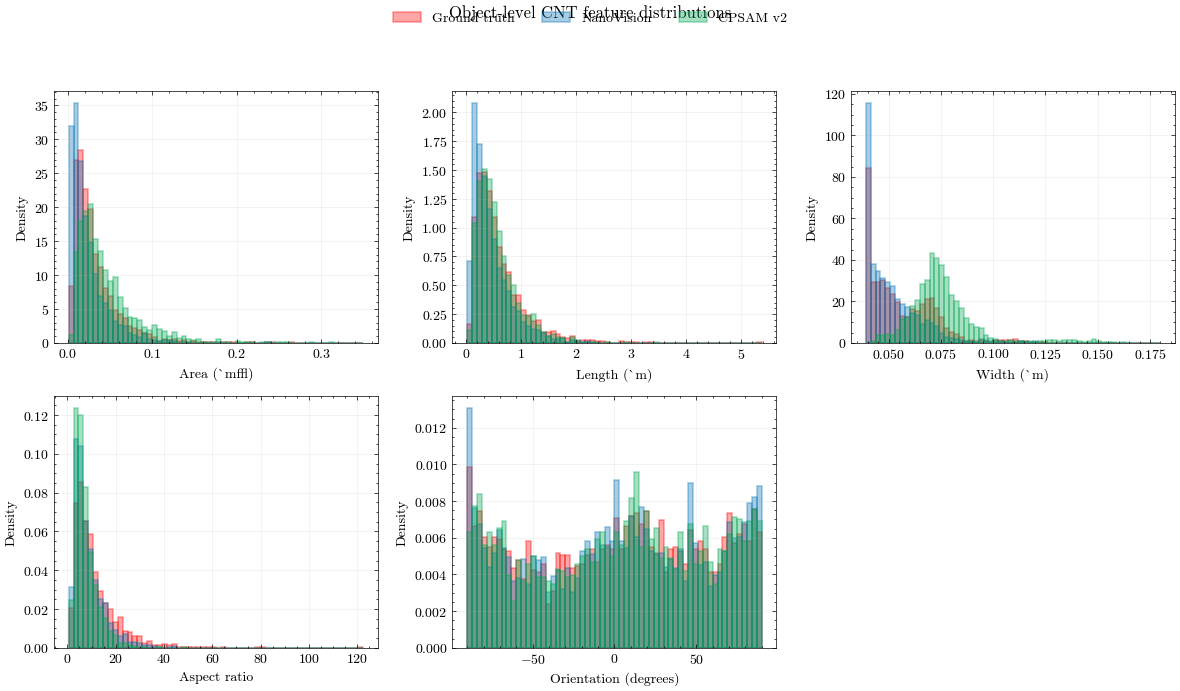

In [40]:
figure, axes = plt.subplots(
    2,
    3,
    figsize=(12, 7),
)

axes = axes.ravel()

for axis, feature in zip(
    axes,
    PLOT_FEATURE_COLUMNS,
):
    combined_values = (
        object_features[feature]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
        .to_numpy()
    )

    bins = np.histogram_bin_edges(
        combined_values,
        bins=60,
    )

    for model in MODEL_ORDER:
        values = (
            object_features.loc[
                object_features["model"] == model,
                feature,
            ]
            .replace(
                [np.inf, -np.inf],
                np.nan,
            )
            .dropna()
        )

        axis.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.35,
            color=MODEL_COLORS[model],
            edgecolor=MODEL_COLORS[model],
            linewidth=1.2,
            label=model,
        )

    axis.set_xlabel(
        FEATURE_LABELS[feature]
    )
    axis.set_ylabel("Density")
    axis.grid(alpha=0.2)

for axis in axes[
    len(PLOT_FEATURE_COLUMNS):
]:
    axis.axis("off")

handles, labels = (
    axes[0].get_legend_handles_labels()
)

figure.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
)

figure.suptitle(
    "Object-level CNT feature distributions",
    y=0.995,
)

figure.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

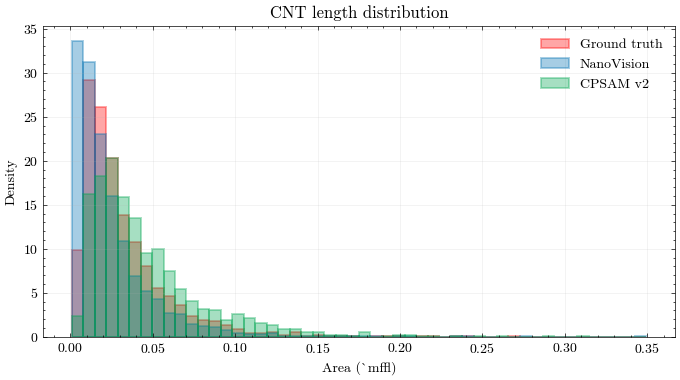

In [41]:
feature = "area_um2"

combined_values = (
    object_features[feature]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
    .to_numpy()
)

bins = np.histogram_bin_edges(
    combined_values,
    bins=50,
)

figure, axis = plt.subplots(
    figsize=(7, 4),
)

for model in MODEL_ORDER:
    values = (
        object_features.loc[
            object_features["model"] == model,
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    axis.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.35,
        color=MODEL_COLORS[model],
        edgecolor=MODEL_COLORS[model],
        linewidth=1.4,
        label=model,
    )

axis.set_xlabel(
    FEATURE_LABELS[feature]
)
axis.set_ylabel("Density")
axis.set_title(
    "CNT length distribution"
)
axis.grid(alpha=0.2)
axis.legend(frameon=False)

figure.tight_layout()
plt.show()

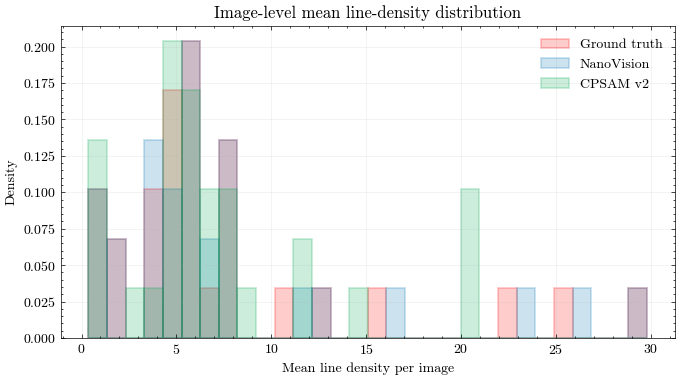

In [44]:
feature = "line_density_mean"

combined_values = (
    image_features[feature]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
    .to_numpy()
)

bins = np.histogram_bin_edges(
    combined_values,
    bins=30,
)

figure, axis = plt.subplots(
    figsize=(7, 4),
)

for model in MODEL_ORDER:
    values = (
        image_features.loc[
            image_features["model"] == model,
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    axis.hist(
        values,
        bins=bins,
        density=True,
        alpha=0.20,
        color=MODEL_COLORS[model],
        edgecolor=MODEL_COLORS[model],
        linewidth=1.4,
        label=model,
    )

axis.set_xlabel(
    "Mean line density per image"
)
axis.set_ylabel("Density")
axis.set_title(
    "Image-level mean line-density distribution"
)
axis.grid(alpha=0.2)
axis.legend(frameon=False)

figure.tight_layout()
plt.show()

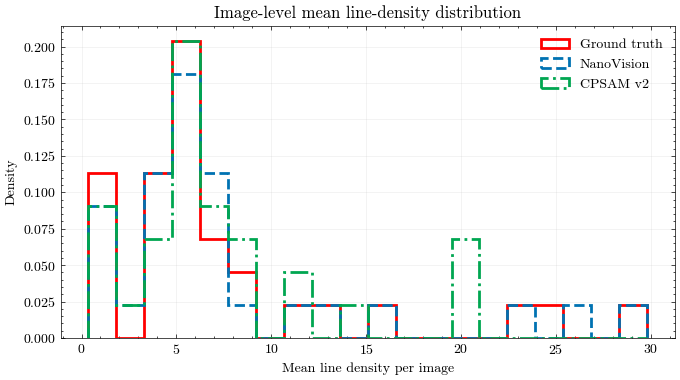

In [43]:
feature = "line_density_mean"

combined_values = (
    image_features[feature]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
    .to_numpy()
)

bins = np.histogram_bin_edges(
    combined_values,
    bins=20,
)

model_linestyles = {
    "Ground truth": "-",
    "NanoVision": "--",
    "CPSAM v2": "-.",
}

figure, axis = plt.subplots(
    figsize=(7, 4),
)

for model in MODEL_ORDER:
    values = (
        image_features.loc[
            image_features["model"] == model,
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    axis.hist(
        values,
        bins=bins,
        density=True,
        histtype="step",
        color=MODEL_COLORS[model],
        linestyle=model_linestyles[model],
        linewidth=2.0,
        label=model,
    )

axis.set_xlabel(
    "Mean line density per image"
)
axis.set_ylabel("Density")
axis.set_title(
    "Image-level mean line-density distribution"
)
axis.grid(alpha=0.2)
axis.legend(frameon=False)

figure.tight_layout()
plt.show()